# TARGET 1 — Order Volume Forecast

**Goal:** Forecast the order count for the next 7 days for each region.  
**Approach:** `orders.parquet` + `weather.parquet` + `holidays.parquet`  
**Region-Day** aggregation → time series features → 6 ML models → comparison  

---
**Models:**
1. Random Forest Regressor  
2. XGBoost Regressor  
3. LightGBM Regressor  
4. CatBoost Regressor  
5. Gradient Boosting Regressor (sklearn)  
6. Ridge Regression (baseline)


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
import joblib
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.model_selection import GridSearchCV

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print(" All libraries loaded successfully!")
print(f"  XGBoost: {xgb.__version__}")
print(f"  LightGBM: {lgb.__version__}")


 All libraries loaded successfully!
  XGBoost: 3.2.0
  LightGBM: 4.6.0


## 1. Loading the Real Data

We load the actual project data directly from the parquet files:  
- `orders.parquet`: order_id, region, item_count, created_at, delivery_type, shipment_id  
- `weather.parquet`: timestamp, region, temperature, rainfall, wind_speed  
- `holidays.parquet`: date, event_name, region

**Fixes applied:**
- `Khankendi` is missing from orders.parquet (only 9 regions) — handled gracefully; REGIONS derived from orders data
- `weather.parquet` timestamp has timezone suffix (`+00:00`) — stripped during load
- `holidays.parquet` date is string format — converted to datetime
- Notebook previously referenced `'Baku'` region (does not exist) — fixed to `'Absheron'`
- `holidays_set` variable was undefined in forecast section — now properly built from parquet


In [29]:
# ─── Load Orders ──────────────────────────────────────────────────
orders_df = pd.read_parquet('orders.parquet')
orders_df['created_at'] = pd.to_datetime(orders_df['created_at'])

# Regions derived from actual data (9 regions in orders, Khankendi absent)
REGIONS = sorted(orders_df['region'].unique())

print(f" Orders: {len(orders_df):,} rows, {len(orders_df.columns)} columns")
print(f"   Date range: {orders_df['created_at'].min()} → {orders_df['created_at'].max()}")
print(f"   Regions ({len(REGIONS)}): {REGIONS}")

# ─── Load Weather ─────────────────────────────────────────────────
weather_df = pd.read_parquet('weather.parquet')
# Strip timezone suffix from timestamp (e.g. '2020-01-01 00:00:00+00:00')
weather_df['timestamp'] = pd.to_datetime(
    weather_df['timestamp'].astype(str).str.replace(r'\+00:00$', '', regex=True)
)
# Keep only regions present in orders
weather_df = weather_df[weather_df['region'].isin(REGIONS)]
print(f" Weather: {len(weather_df):,} rows | regions: {sorted(weather_df['region'].unique())}")

# ─── Load Holidays ────────────────────────────────────────────────
holidays_df = pd.read_parquet('holidays.parquet')
holidays_df['date'] = pd.to_datetime(holidays_df['date'])
# Build holidays_set (set of date strings YYYY-MM-DD) for fast lookup
holidays_set = set(holidays_df['date'].dt.strftime('%Y-%m-%d'))
print(f" Holidays: {len(holidays_df)} rows | {min(holidays_set)} → {max(holidays_set)}")


 Orders: 110,000 rows, 6 columns
   Date range: 2020-01-01 00:49:03 → 2026-06-12 23:06:16
   Regions (10): ['Absheron', 'Ganja', 'Kalbajar', 'Khachmaz', 'Khankendi', 'Lankaran', 'Nakhchivan', 'Qazakh', 'Sheki', 'Yevlakh']
 Weather: 23,570 rows | regions: ['Absheron', 'Ganja', 'Kalbajar', 'Khachmaz', 'Khankendi', 'Lankaran', 'Nakhchivan', 'Qazakh', 'Sheki', 'Yevlakh']
 Holidays: 135 rows | 2020-01-01 → 2026-12-31


## 2. Feature Engineering

**Why these features?**  
- **Lag features:** Past orders are the strongest signal for forecasting the future  
- **Rolling averages:** Smooth out the trend and protect against short-term noise  
- **Time components:** Capture weekly/monthly seasonality  
- **Weather:** Rain and temperature change ordering behavior  
- **Holiday flags:** Critical for forecasting peaks


In [30]:
# ─── Daily aggregation ────────────────────────────────────────────
orders_df['date'] = orders_df['created_at'].dt.normalize()   # BUG 1 FIX

daily = (orders_df.groupby(['date', 'region'])
         .agg(order_count=('order_id', 'count'),
              avg_item_count=('item_count', 'mean'),
              express_ratio=('delivery_type', lambda x: (x == 'express').mean()))
         .reset_index())
daily['date'] = pd.to_datetime(daily['date'])

# ─── Weather aggregation ─────────────────────────────────────────
weather_df['date'] = weather_df['timestamp'].dt.normalize()  # BUG 2 FIX
weather_agg = (weather_df.groupby(['date', 'region'])
               .agg(temperature=('temperature', 'mean'),
                    rainfall=('rainfall', 'sum'),
                    wind_speed=('wind_speed', 'mean'))
               .reset_index())

daily = daily.merge(weather_agg, on=['date', 'region'], how='left')

# ─── Holiday flag ────────────────────────────────────────────────
daily['date_str']   = daily['date'].dt.strftime('%Y-%m-%d')
daily['is_holiday'] = daily['date_str'].isin(holidays_set).astype(int)
daily.drop(columns=['date_str'], inplace=True)

# ─── Time features ───────────────────────────────────────────────
daily['dayofweek']    = daily['date'].dt.dayofweek
daily['month']        = daily['date'].dt.month
daily['quarter']      = daily['date'].dt.quarter
daily['year']         = daily['date'].dt.year
daily['dayofyear']    = daily['date'].dt.dayofyear
daily['week']         = daily['date'].dt.isocalendar().week.astype(int)
daily['is_weekend']   = (daily['dayofweek'] >= 5).astype(int)
daily['is_month_end'] = daily['date'].dt.is_month_end.astype(int)
daily['sin_dow']      = np.sin(2 * np.pi * daily['dayofweek'] / 7)
daily['cos_dow']      = np.cos(2 * np.pi * daily['dayofweek'] / 7)
daily['sin_month']    = np.sin(2 * np.pi * daily['month'] / 12)
daily['cos_month']    = np.cos(2 * np.pi * daily['month'] / 12)
daily['trend']        = (daily['date'] - daily['date'].min()).dt.days

daily = daily.sort_values(['region', 'date']).reset_index(drop=True)

# ─── Lag features ────────────────────────────────────────────────
for lag in [1, 2, 3, 7, 14, 21, 28]:
    daily[f'lag_{lag}'] = daily.groupby('region')['order_count'].shift(lag)

for lag in [364, 365, 366]:
    daily[f'lag_{lag}'] = daily.groupby('region')['order_count'].shift(lag)

# ─── Rolling features ────────────────────────────────────────────
for window in [3, 7, 14, 28]:
    daily[f'rolling_mean_{window}'] = (
        daily.groupby('region')['order_count']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean()))
    daily[f'rolling_std_{window}'] = (
        daily.groupby('region')['order_count']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0)))

daily['rolling_mean_365'] = (
    daily.groupby('region')['order_count']
    .transform(lambda x: x.shift(1).rolling(365, min_periods=30).mean()))

daily['same_dow_last_week'] = (
    daily.groupby(['region', 'dayofweek'])['order_count'].shift(1))

# ─── Holiday proximity ───────────────────────────────────────────
import bisect
hol_sorted = sorted(holidays_df['date'].tolist())
hol_set    = set(hol_sorted)

def days_to_nearest_holiday(d):
    idx  = bisect.bisect_left(hol_sorted, d)
    best = 999
    if idx < len(hol_sorted):
        best = min(best, (hol_sorted[idx] - d).days)
    if idx > 0:
        best = min(best, abs((d - hol_sorted[idx - 1]).days))
    return best

daily['days_to_holiday']  = daily['date'].apply(days_to_nearest_holiday)
daily['is_holiday_eve']   = daily['date'].apply(
    lambda d: int((d + pd.Timedelta(days=1)) in hol_set))
daily['is_holiday_after'] = daily['date'].apply(
    lambda d: int((d - pd.Timedelta(days=1)) in hol_set))

# ─── Region encoding + weather fill ─────────────────────────────
le = LabelEncoder()
daily['region_enc'] = le.fit_transform(daily['region'])

for col in ['temperature', 'rainfall', 'wind_speed']:
    daily[col] = daily.groupby(['region', 'month'])[col].transform(
        lambda x: x.fillna(x.median()))
    daily[col] = daily[col].fillna(daily[col].median())

daily_clean = daily.dropna().copy()

print(f"Feature engineering complete.")
print(f"Rows after dropna : {len(daily_clean):,}")
print(f"Total columns     : {len(daily_clean.columns)}")

Feature engineering complete.
Rows after dropna : 15,792
Total columns     : 46


## 3. Exploratory Data Analysis (EDA)

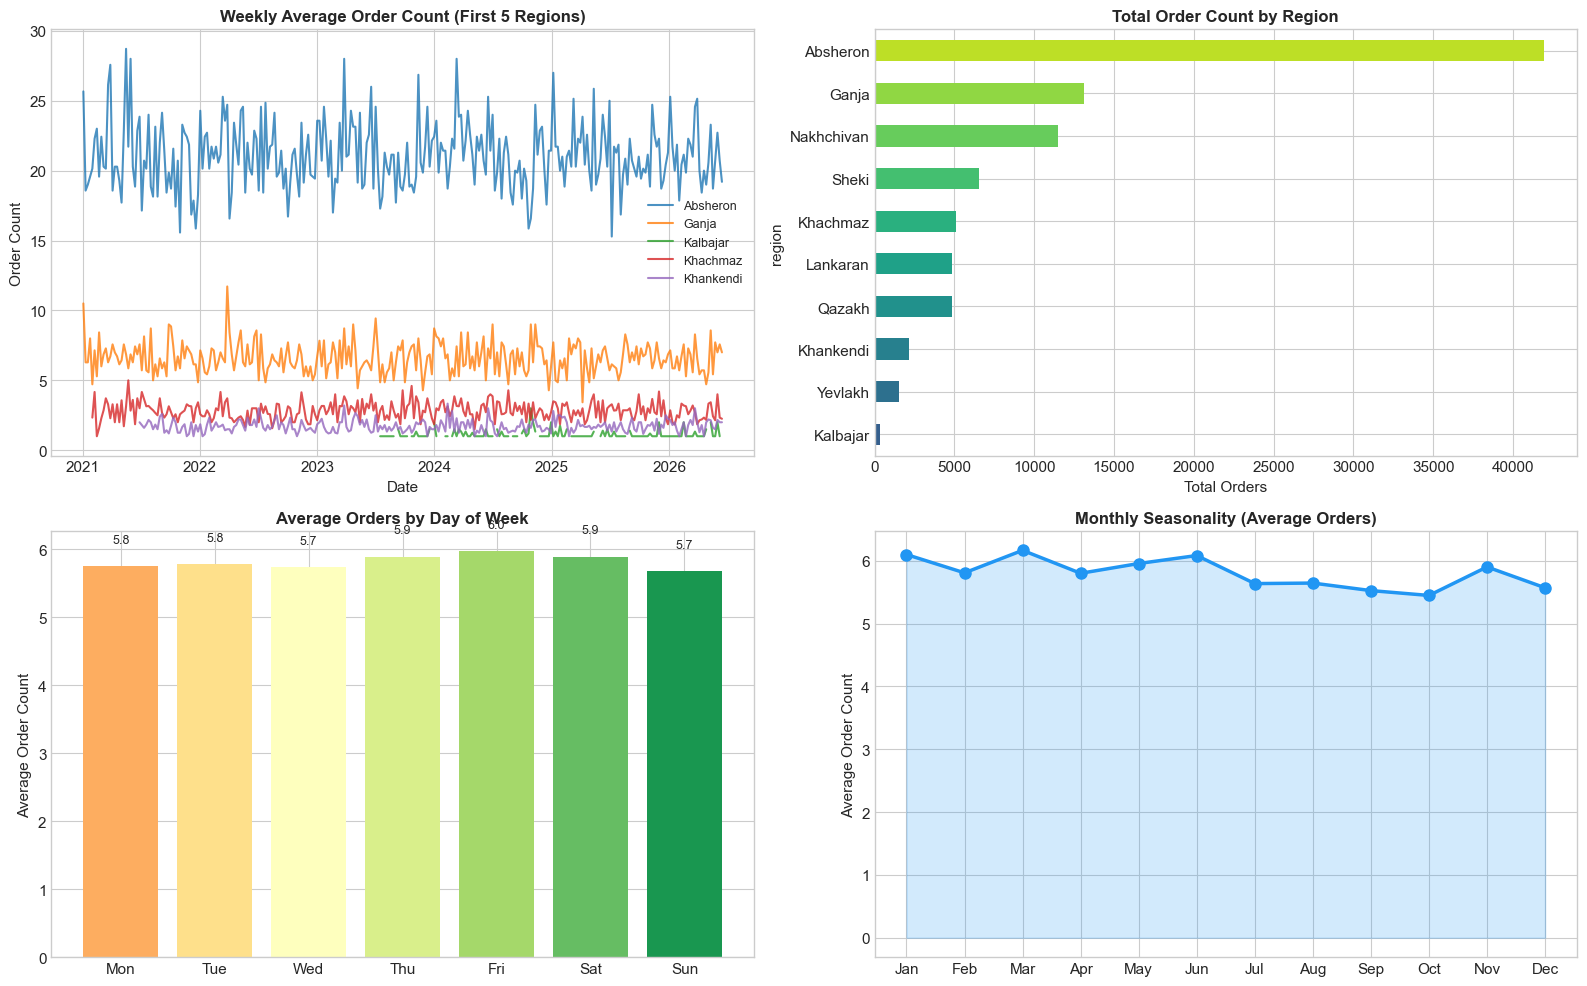

 EDA visualization complete!


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Daily order count by region (weekly resample)
ax = axes[0, 0]
for region in REGIONS[:5]:
    sub = daily_clean[daily_clean['region'] == region].set_index('date')['order_count']
    sub_weekly = sub.resample('W').mean()
    ax.plot(sub_weekly.index, sub_weekly.values, label=region, alpha=0.8, linewidth=1.5)
ax.set_title('Weekly Average Order Count (First 5 Regions)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Order Count')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Plot 2: Total order share by region
ax = axes[0, 1]
region_totals = daily_clean.groupby('region')['order_count'].sum().sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(region_totals)))
region_totals.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Total Order Count by Region', fontsize=12, fontweight='bold')
ax.set_xlabel('Total Orders')

# Plot 3: Day-of-week effect
ax = axes[1, 0]
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_means = daily_clean.groupby('dayofweek')['order_count'].mean()
bars = ax.bar(dow_labels, dow_means.values, color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 7)))
ax.set_title('Average Orders by Day of Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Order Count')
for bar, val in zip(bars, dow_means.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

# Plot 4: Monthly seasonality
ax = axes[1, 1]
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_means = daily_clean.groupby('month')['order_count'].mean()
ax.plot(range(1, 13), month_means.values, 'o-', linewidth=2.5,
        markersize=8, color='#2196F3')
ax.fill_between(range(1, 13), month_means.values, alpha=0.2, color='#2196F3')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Monthly Seasonality (Average Orders)', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Order Count')

plt.tight_layout()
plt.show()
print(" EDA visualization complete!")


## 4. Train/Test Split

**Why a time-based split?**  
To avoid leaking the future into the past in a time series, we hold out the last 60 days as the test set.  
This mirrors a real deployment scenario.


In [32]:
daily = daily.sort_values(['region', 'date']).reset_index(drop=True)

for lag in [1, 2, 3, 7, 14, 21, 28]:
    daily[f'lag_{lag}'] = daily.groupby('region')['order_count'].shift(lag)

for lag in [364, 365, 366]:
    daily[f'lag_{lag}'] = daily.groupby('region')['order_count'].shift(lag)

for window in [3, 7, 14, 28]:
    daily[f'rolling_mean_{window}'] = (
        daily.groupby('region')['order_count']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean()))
    daily[f'rolling_std_{window}'] = (
        daily.groupby('region')['order_count']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0)))

daily['rolling_mean_365'] = (
    daily.groupby('region')['order_count']
    .transform(lambda x: x.shift(1).rolling(365, min_periods=30).mean()))

daily['same_dow_last_week'] = daily.groupby(['region', 'dayofweek'])['order_count'].shift(1)

import bisect
hol_sorted = sorted(holidays_df['date'].tolist())
hol_set    = set(hol_sorted)

def days_to_nearest_holiday(d):
    idx  = bisect.bisect_left(hol_sorted, d)
    best = 999
    if idx < len(hol_sorted):
        best = min(best, (hol_sorted[idx] - d).days)
    if idx > 0:
        best = min(best, abs((d - hol_sorted[idx - 1]).days))
    return best

daily['days_to_holiday']  = daily['date'].apply(days_to_nearest_holiday)
daily['is_holiday_eve']   = daily['date'].apply(
    lambda d: int((d + pd.Timedelta(days=1)) in hol_set))
daily['is_holiday_after'] = daily['date'].apply(
    lambda d: int((d - pd.Timedelta(days=1)) in hol_set))

le = LabelEncoder()
daily['region_enc'] = le.fit_transform(daily['region'])

for col in ['temperature', 'rainfall', 'wind_speed']:
    daily[col] = daily.groupby(['region', 'month'])[col].transform(
        lambda x: x.fillna(x.median()))
    daily[col] = daily[col].fillna(daily[col].median())

daily_clean = daily.dropna().copy()
print(f" Feature engineering complete!")
print(f"   Rows after dropna: {len(daily_clean):,}")
print(f"   Columns: {len(daily_clean.columns)}")

 Feature engineering complete!
   Rows after dropna: 15,792
   Columns: 46


In [33]:
FEATURE_COLS = [
    # Time
    'dayofweek','month','quarter','year','dayofyear','week',
    'is_weekend','is_month_end','is_holiday','trend',
    'sin_dow','cos_dow','sin_month','cos_month',
    # Lag — standart
    'lag_1','lag_2','lag_3','lag_7','lag_14','lag_21','lag_28',
    # Lag — keçən il
    'lag_364','lag_365','lag_366',
    # Rolling — standart
    'rolling_mean_3','rolling_mean_7','rolling_mean_14','rolling_mean_28',
    'rolling_std_3','rolling_std_7','rolling_std_14','rolling_std_28',
    # Rolling — illik
    'rolling_mean_365',
    'same_dow_last_week',
    # Holiday proximity
    'days_to_holiday','is_holiday_eve','is_holiday_after',
    # Weather
    'temperature','rainfall','wind_speed',
    # Other
    'avg_item_count','express_ratio','region_enc',
]

TARGET_COL  = 'order_count'
cutoff_date = pd.Timestamp('2026-04-13')

train_df = daily_clean[daily_clean['date'] < cutoff_date].copy()
test_df  = daily_clean[daily_clean['date'] >= cutoff_date].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

print(f" Train: {len(X_train):,} rows  ({train_df['date'].min().date()} → {train_df['date'].max().date()})")
print(f" Test : {len(X_test):,} rows  ({test_df['date'].min().date()} → {test_df['date'].max().date()})")
print(f" Features: {len(FEATURE_COLS)}")
print(f" Target mean={y_train.mean():.2f}, std={y_train.std():.2f}")

 Train: 15,286 rows  (2021-01-01 → 2026-04-12)
 Test : 506 rows  (2026-04-13 → 2026-06-12)
 Features: 43
 Target mean=5.82, std=6.52


## 5. ML Model Tuning and Training

**Hyperparameter tuning:** RandomizedSearchCV + TimeSeriesSplit(5-fold)  
**Why TimeSeriesSplit?** To test the future using the past in a time series.


In [34]:
# ─── Unified evaluate_model (train+test, no refit) ───────────────────────
results     = {}
best_models = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    pred_tr = np.maximum(model.predict(X_tr), 0)
    pred_te = np.maximum(model.predict(X_te), 0)
    res = {
        'Train_MAE':   mean_absolute_error(y_tr, pred_tr),
        'Train_RMSE':  np.sqrt(mean_squared_error(y_tr, pred_tr)),
        'Train_R2':    r2_score(y_tr, pred_tr),
        'Test_MAE':    mean_absolute_error(y_te, pred_te),
        'Test_RMSE':   np.sqrt(mean_squared_error(y_te, pred_te)),
        'Test_R2':     r2_score(y_te, pred_te),
        'MAPE':        np.mean(np.abs((y_te - pred_te) / (y_te + 1e-6))) * 100,
        'predictions': pred_te,
        'model_obj':   model,
    }
    return res

In [35]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 1: Random Forest
# ═══════════════════════════════════════════════════════════════════
print("Model 1: Random Forest Regressor")

rf_param_grid = {
    'n_estimators':      [253],
    'max_depth':         [7],
    'min_samples_split': [10],
    'min_samples_leaf':  [10],
    'max_features':      [0.78],
    'bootstrap':         [False, True],
}
total_combinations = np.prod([len(v) for v in rf_param_grid.values()])
print(f"    GridSearchCV Fits: {total_combinations * 10} fits\n")

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid, cv=10, scoring='r2', n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_

results['RandomForest']     = evaluate_model('RandomForest', best_rf, X_train, y_train, X_test, y_test)
best_models['RandomForest'] = best_rf

r = results['RandomForest']
print(f"    Best params : {rf_search.best_params_}")
print(f"    Train → MAE={r['Train_MAE']:.3f}  RMSE={r['Train_RMSE']:.3f}  R²={r['Train_R2']:.4f}")
print(f"    Test  → MAE={r['Test_MAE']:.3f}  RMSE={r['Test_RMSE']:.3f}  R²={r['Test_R2']:.4f}\n")

Model 1: Random Forest Regressor
    GridSearchCV Fits: 20 fits

    Best params : {'bootstrap': True, 'max_depth': 7, 'max_features': 0.78, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 253}
    Train → MAE=1.288  RMSE=1.996  R²=0.9062
    Test  → MAE=1.403  RMSE=2.224  R²=0.8776



In [36]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 2: XGBoost
# ═══════════════════════════════════════════════════════════════════
print("Model 2: XGBoost Regressor")

xgb_param_grid = {
    'n_estimators':     [100],
    'learning_rate':    [0.24],
    'max_depth':        [3],
    'subsample':        [1],
    'colsample_bytree': [0.8],
    'min_child_weight': [1],
    'reg_alpha':        [0.0],
    'reg_lambda':       [8.0],
    'gamma':            [0.0],
}
total_combinations = np.prod([len(v) for v in xgb_param_grid.values()])
print(f"    GridSearchCV Fits: {total_combinations * 10} fits\n")

xgb_search = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0, objective='reg:squarederror'),
    xgb_param_grid, cv=10, scoring='r2', n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

results['XGBoost']     = evaluate_model('XGBoost', best_xgb, X_train, y_train, X_test, y_test)
best_models['XGBoost'] = best_xgb

r = results['XGBoost']
print(f"    Best params : {xgb_search.best_params_}")
print(f"    Train → MAE={r['Train_MAE']:.3f}  RMSE={r['Train_RMSE']:.3f}  R²={r['Train_R2']:.4f}")
print(f"    Test  → MAE={r['Test_MAE']:.3f}  RMSE={r['Test_RMSE']:.3f}  R²={r['Test_R2']:.4f}\n")

Model 2: XGBoost Regressor
    GridSearchCV Fits: 10 fits

    Best params : {'colsample_bytree': 0.8, 'gamma': 0.0, 'learning_rate': 0.24, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 0.0, 'reg_lambda': 8.0, 'subsample': 1}
    Train → MAE=1.179  RMSE=1.792  R²=0.9244
    Test  → MAE=1.292  RMSE=2.102  R²=0.8906



In [37]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 3: LightGBM
# ═══════════════════════════════════════════════════════════════════
print("Model 3: LightGBM Regressor")

lgb_params = {
    'boosting_type': 'gbdt', 
    'objective': 'regression',
    'num_leaves': 71, 
    'max_depth': 9, 
    'learning_rate': 0.0315783,
    'n_estimators': 376, 
    'subsample_for_bin': 200000,
    'min_split_gain': 0.0, 
    'min_child_weight': 0.001,
    'min_child_samples': 36, 
    'subsample': 0.941667,
    'subsample_freq': 1, 
    'colsample_bytree': 0.65587,
    'reg_alpha': 0.14835, 
    'reg_lambda': 0.591667,
    'random_state': 42, 
    'n_jobs': -1, 
    'verbose': -1,
}

best_lgb = lgb.LGBMRegressor(**lgb_params)

CV_FOLDS = 10
cv_r2 = cross_val_score(best_lgb, X_train, y_train, cv=CV_FOLDS, scoring='r2', n_jobs=-1)
print(f"    CV R² (mean ± std): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

best_lgb.fit(X_train, y_train)
results['LightGBM']     = evaluate_model('LightGBM', best_lgb, X_train, y_train, X_test, y_test)
best_models['LightGBM'] = best_lgb

r = results['LightGBM']
print(f"    Train → MAE={r['Train_MAE']:.3f}  RMSE={r['Train_RMSE']:.3f}  R²={r['Train_R2']:.4f}")
print(f"    Test  → MAE={r['Test_MAE']:.3f}  RMSE={r['Test_RMSE']:.3f}  R²={r['Test_R2']:.4f}\n")

Model 3: LightGBM Regressor
    CV R² (mean ± std): 0.6178 ± 0.1994
    Train → MAE=0.881  RMSE=1.314  R²=0.9594
    Test  → MAE=1.205  RMSE=2.080  R²=0.8929



In [38]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 4: CatBoost
# ═══════════════════════════════════════════════════════════════════
print("Model 4: CatBoost Regressor")

cat_params = {
    'iterations': 3000,          
    'learning_rate': 0.005,     
    'depth': 6,                
    'l2_leaf_reg': 9,          
    'random_strength': 2,     
    'subsample': 0.8,        
    'loss_function': 'RMSE',
    'border_count': 128,
    'boosting_type': 'Plain',
    'allow_writing_files': False,
    'random_state': 42,
    'verbose': 100,            
}

best_cat = CatBoostRegressor(**cat_params)

CV_FOLDS = 10
cv_r2 = cross_val_score(best_cat, X_train, y_train, cv=CV_FOLDS, scoring='r2', n_jobs=-1)
print(f"    CV R² (mean ± std): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

best_cat.fit(X_train, y_train)
results['CatBoost']     = evaluate_model('CatBoost', best_cat, X_train, y_train, X_test, y_test)
best_models['CatBoost'] = best_cat

r = results['CatBoost']
print(f"    Train → MAE={r['Train_MAE']:.3f}  RMSE={r['Train_RMSE']:.3f}  R²={r['Train_R2']:.4f}")
print(f"    Test  → MAE={r['Test_MAE']:.3f}  RMSE={r['Test_RMSE']:.3f}  R²={r['Test_R2']:.4f}\n")

Model 4: CatBoost Regressor
    CV R² (mean ± std): 0.4991 ± 0.2037
0:	learn: 6.4897938	total: 8.5ms	remaining: 25.5s
100:	learn: 4.4635871	total: 321ms	remaining: 9.21s
200:	learn: 3.3511453	total: 622ms	remaining: 8.67s
300:	learn: 2.7666254	total: 926ms	remaining: 8.3s
400:	learn: 2.4727861	total: 1.23s	remaining: 7.95s
500:	learn: 2.3258302	total: 1.52s	remaining: 7.61s
600:	learn: 2.2486630	total: 1.82s	remaining: 7.29s
700:	learn: 2.2034535	total: 2.13s	remaining: 6.97s
800:	learn: 2.1749220	total: 2.42s	remaining: 6.65s
900:	learn: 2.1549947	total: 2.72s	remaining: 6.33s
1000:	learn: 2.1395437	total: 3.02s	remaining: 6.02s
1100:	learn: 2.1261769	total: 3.31s	remaining: 5.71s
1200:	learn: 2.1148260	total: 3.6s	remaining: 5.4s
1300:	learn: 2.1035912	total: 3.9s	remaining: 5.1s
1400:	learn: 2.0936771	total: 4.19s	remaining: 4.79s
1500:	learn: 2.0832478	total: 4.49s	remaining: 4.48s
1600:	learn: 2.0737611	total: 4.79s	remaining: 4.18s
1700:	learn: 2.0646578	total: 5.08s	remaining: 3

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 5: Gradient Boosting
# ═══════════════════════════════════════════════════════════════════
print("Model 5: Gradient Boosting Regressor")

gb_param_grid = {
    'learning_rate':    [0.1233326707814573],
    'loss':             ['huber'],
    'max_depth':        [8],
    'max_features':     [0.6],
    'max_leaf_nodes':   [30],
    'min_samples_leaf': [15],
    'min_samples_split':[4],
    'n_estimators':     [285],
    'subsample':        [0.9521871356061031],
}
total_combinations = np.prod([len(v) for v in gb_param_grid.values()])
print(f"    GridSearchCV Fits: {total_combinations * 10} fits\n")

gb_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid, cv=10, scoring='r2', n_jobs=-1, verbose=0
)
gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_

results['GradientBoosting']     = evaluate_model('GradientBoosting', best_gb, X_train, y_train, X_test, y_test)
best_models['GradientBoosting'] = best_gb

r = results['GradientBoosting']
print(f"    Best params : {gb_search.best_params_}")
print(f"    Train → MAE={r['Train_MAE']:.3f}  RMSE={r['Train_RMSE']:.3f}  R²={r['Train_R2']:.4f}")
print(f"    Test  → MAE={r['Test_MAE']:.3f}  RMSE={r['Test_RMSE']:.3f}  R²={r['Test_R2']:.4f}\n")

Model 5: Gradient Boosting Regressor
    GridSearchCV Fits: 10 fits



In [ ]:
# ═══════════════════════════════════════════════════════════════════
# MODEL 6: Ridge Regression
# ═══════════════════════════════════════════════════════════════════
print("Model 6: Ridge Regression")

ridge_param_grid = {'alpha': np.linspace(1.0, 100.0, 50)}
print(f"    GridSearchCV Fits: {len(ridge_param_grid['alpha']) * 10} fits\n")

ridge_search = GridSearchCV(
    Ridge(), ridge_param_grid, cv=10, scoring='r2', n_jobs=-1, verbose=0
)
ridge_search.fit(X_train, y_train)
best_ridge = ridge_search.best_estimator_

results['Ridge']     = evaluate_model('Ridge', best_ridge, X_train, y_train, X_test, y_test)
best_models['Ridge'] = best_ridge

r = results['Ridge']
print(f"    Best alpha  : {ridge_search.best_params_['alpha']:.4f}")
print(f"    Train → MAE={r['Train_MAE']:.3f}  RMSE={r['Train_RMSE']:.3f}  R²={r['Train_R2']:.4f}")
print(f"    Test  → MAE={r['Test_MAE']:.3f}  RMSE={r['Test_RMSE']:.3f}  R²={r['Test_R2']:.4f}\n")

## 6. Model Comparison and Visualization

In [ ]:
metrics_df = pd.DataFrame({
    name: {
        'Train MAE':  r['Train_MAE'],
        'Train RMSE': r['Train_RMSE'],
        'Train R²':   r['Train_R2'],
        'Test MAE':   r['Test_MAE'],
        'Test RMSE':  r['Test_RMSE'],
        'Test R²':    r['Test_R2'],
        'MAPE (%)':   r['MAPE'],
    }
    for name, r in results.items()
}).T.sort_values('Test MAE')

print("\n" + "="*72)
print(" TARGET 1 — MODEL COMPARISON (Train vs Test)")
print("="*72)
print(metrics_df.round(4).to_string())
print("="*72)
print(f"\n Best Model (Test MAE) : {metrics_df['Test MAE'].idxmin()}")
print(f" Best Model (Test R²)  : {metrics_df['Test R²'].idxmax()}")

In [ ]:
# ─── Visualization ───────────────────────────────────────────────
best_key       = metrics_df['Test MAE'].idxmin()
best_preds     = results[best_key]['predictions']
best_model_obj = results[best_key]['model_obj']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

model_colors = {
    'RandomForest':     '#4CAF50',
    'XGBoost':          '#2196F3',
    'LightGBM':         '#FF9800',
    'CatBoost':         '#9C27B0',
    'GradientBoosting': '#F44336',
    'Ridge':            '#607D8B',
}
names   = list(metrics_df.index)
colors  = [model_colors.get(n, '#888') for n in names]

# Plot 1: Test MAE
ax = axes[0, 0]
vals = metrics_df['Test MAE'].values
bars = ax.bar(names, vals, color=colors, edgecolor='white')
ax.set_title('Test MAE (Lower = Better)', fontweight='bold')
ax.set_ylabel('MAE')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

# Plot 2: Test R²
ax = axes[0, 1]
vals = metrics_df['Test R²'].values
bars = ax.bar(names, vals, color=colors, edgecolor='white')
ax.set_title('Test R² (Higher = Better)', fontweight='bold')
ax.set_ylabel('R²')
ax.set_ylim([max(0, vals.min()*0.95), 1.0])
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

# Plot 3: MAPE
ax = axes[0, 2]
vals = metrics_df['MAPE (%)'].values
bars = ax.bar(names, vals, color=colors, edgecolor='white')
ax.set_title('MAPE % (Lower = Better)', fontweight='bold')
ax.set_ylabel('MAPE (%)')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

# Plot 4: Actual vs Predicted scatter
ax = axes[1, 0]
sample = min(300, len(y_test))
ax.scatter(y_test.values[:sample], best_preds[:sample], alpha=0.4, s=20, color='#2196F3')
mv = max(y_test.max(), best_preds.max())
ax.plot([0, mv], [0, mv], 'r--', linewidth=2, label='Perfect')
ax.set_title(f'{best_key} — Actual vs Predicted', fontweight='bold')
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted'); ax.legend()

# Plot 5: Absheron time series
ax = axes[1, 1]
ab_test = test_df[test_df['region'] == 'Absheron'].copy().reset_index(drop=True)
ab_idx  = test_df[test_df['region'] == 'Absheron'].index - test_df.index[0]
ab_pred = best_preds[ab_idx]
ax.plot(ab_test['date'].values, ab_test['order_count'].values, 'b-', label='Actual', linewidth=2)
ax.plot(ab_test['date'].values, ab_pred, 'r--', label=f'{best_key}', linewidth=2)
ax.set_title(f'Absheron — Actual vs Forecast', fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Order Count'); ax.legend()

# Plot 6: Feature Importance
ax = axes[1, 2]
if hasattr(best_model_obj, 'feature_importances_'):
    fi = pd.Series(best_model_obj.feature_importances_, index=FEATURE_COLS)
    fi.nlargest(15).sort_values().plot(kind='barh', ax=ax, color='#2196F3')
    ax.set_title(f'Top 15 Features ({best_key})', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('TARGET 1 — Order Volume Forecast: Model Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(" Visualization complete!")

## 7. 7-Day Forecast (by Region)

In [ ]:
def recursive_forecast_7day(model, daily_clean, region, future_dates,
                             feature_cols, holidays_set, hol_sorted, weather_df, le,
                             train_df):

    reg_hist = (daily_clean[daily_clean['region'] == region]
                .sort_values('date').copy())

    # Guard: if no history exists for this region, return zeros
    if len(reg_hist) == 0:
        print(f"  WARNING: no history for region '{region}', returning zeros.")
        return [0.0] * len(future_dates)

    series  = reg_hist.set_index('date')['order_count'].astype(float).copy()
    global_min_date = daily_clean['date'].min()

    # Safe lookup: returns value from series if date exists, else fallback
    def get_value(s, date):
        if date in s.index:
            return float(s[date])
        if len(s) == 0:
            return 0.0
        return float(s.iloc[-1])

    # Precompute region-level averages from training data once
    reg_tr = train_df[train_df['region'] == region]
    avg_item_count = float(reg_tr['avg_item_count'].mean()) if len(reg_tr) > 0 else 1.0
    express_ratio  = float(reg_tr['express_ratio'].mean())  if len(reg_tr) > 0 else 0.0

    hol_set = set(hol_sorted)

    preds = []
    for fdate in future_dates:

        row = {
            'dayofweek':        fdate.dayofweek,
            'month':            fdate.month,
            'quarter':          fdate.quarter,
            'year':             fdate.year,
            'dayofyear':        fdate.dayofyear,
            'week':             int(fdate.isocalendar().week),
            'is_weekend':       int(fdate.dayofweek >= 5),
            'is_month_end':     int(fdate.is_month_end),
            'is_holiday':       int(fdate.strftime('%Y-%m-%d') in holidays_set),
            'trend':            (fdate - global_min_date).days,
            'sin_dow':          np.sin(2 * np.pi * fdate.dayofweek / 7),
            'cos_dow':          np.cos(2 * np.pi * fdate.dayofweek / 7),
            'sin_month':        np.sin(2 * np.pi * fdate.month / 12),
            'cos_month':        np.cos(2 * np.pi * fdate.month / 12),
            'region_enc':       int(le.transform([region])[0]),
            'days_to_holiday':  days_to_nearest_holiday(fdate),
            'is_holiday_eve':   int((fdate + pd.Timedelta(days=1)) in hol_set),
            'is_holiday_after': int((fdate - pd.Timedelta(days=1)) in hol_set),
            'avg_item_count':   avg_item_count,
            'express_ratio':    express_ratio,
        }

        # Lag features — series already contains previously predicted days
        for lag in [1, 2, 3, 7, 14, 21, 28, 364, 365, 366]:
            past = fdate - pd.Timedelta(days=lag)
            row[f'lag_{lag}'] = get_value(series, past)

        # Rolling features over the live series (includes predicted days)
        for win in [3, 7, 14, 28]:
            tail = series.iloc[-win:] if len(series) >= win else series
            row[f'rolling_mean_{win}'] = float(tail.mean()) if len(tail) > 0 else 0.0
            row[f'rolling_std_{win}']  = float(tail.std())  if len(tail) > 1 else 0.0

        tail_365 = series.iloc[-365:] if len(series) >= 365 else series
        row['rolling_mean_365'] = float(tail_365.mean()) if len(tail_365) > 0 else 0.0

        # Same day of week last week
        same_dow = fdate - pd.Timedelta(weeks=1)
        row['same_dow_last_week'] = get_value(series, same_dow)

        # Weather: historical monthly average for this region
        sw = weather_df[
            (weather_df['timestamp'].dt.month == fdate.month) &
            (weather_df['region'] == region)
        ]
        row['temperature'] = float(sw['temperature'].mean()) if len(sw) > 0 else 15.0
        row['rainfall']    = float(sw['rainfall'].mean())    if len(sw) > 0 else 2.0
        row['wind_speed']  = float(sw['wind_speed'].mean())  if len(sw) > 0 else 15.0

        # Predict
        X_row = pd.DataFrame([row])[feature_cols]
        yhat  = float(max(0.0, model.predict(X_row)[0]))
        preds.append(yhat)

        # Append prediction to series so next day can use it as a lag
        series.loc[fdate] = yhat

    return preds

In [ ]:
last_date    = daily_clean['date'].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=7, freq='D')

best_key       = metrics_df['Test MAE'].idxmin()
best_model_obj = results[best_key]['model_obj']

print(f"Generating 7-day recursive forecast with model: {best_key}")
print(f"Forecast window: {future_dates[0].date()} to {future_dates[-1].date()}\n")

forecast_records = []
for region in REGIONS:
    day_preds = recursive_forecast_7day(
        model        = best_model_obj,
        daily_clean  = daily_clean,
        region       = region,
        future_dates = future_dates,
        feature_cols = FEATURE_COLS,
        holidays_set = holidays_set,
        hol_sorted   = hol_sorted,
        weather_df   = weather_df,
        le           = le,
        train_df     = train_df,
    )
    for fdate, pred in zip(future_dates, day_preds):
        forecast_records.append({
            'Region':            region,
            'Date':              fdate.date(),
            'Day of Week':       ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][fdate.dayofweek],
            'Forecast (Orders)': int(round(pred)),
        })

forecast_df = pd.DataFrame(forecast_records)
pivot = forecast_df.pivot(index='Region', columns='Date', values='Forecast (Orders)')
pivot['TOTAL (7 days)'] = pivot.sum(axis=1)
pivot = pivot.sort_values('TOTAL (7 days)', ascending=False)

print("=" * 80)
print(f"TARGET 1  --  {future_dates[0].date()} to {future_dates[-1].date()}  (7-Day Recursive Forecast)")
print(f"Model: {best_key}  |  Test MAE: {results[best_key]['Test_MAE']:.3f}  |  Test R2: {results[best_key]['Test_R2']:.4f}")
print("=" * 80)
print(pivot.to_string())
print("=" * 80)
print(f"Total forecast (all regions, 7 days): {pivot['TOTAL (7 days)'].sum():,} orders")

In [ ]:
# ─── Forecast Visualization ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
heatmap_data = pivot.drop(columns=['TOTAL (7 days)'])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Order Count'})
ax.set_title('7-Day Order Forecast (Heatmap)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Region')

ax = axes[1]
total_by_region = pivot['TOTAL (7 days)']
colors_bar = plt.cm.plasma(np.linspace(0.3, 0.9, len(total_by_region)))
total_by_region.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white')
ax.set_title('7-Day Total Forecast by Region', fontsize=12, fontweight='bold')
ax.set_xlabel('Region'); ax.set_ylabel('Total Orders')
ax.tick_params(axis='x', rotation=30)
for i, (_, val) in enumerate(total_by_region.items()):
    ax.text(i, val + 5, str(int(val)), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle(f'TARGET 1 — 7-Day Forecast ({best_key})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(" Forecast visualization complete!")